In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Q3 - Superimpose flag on cricket turf

### Click 4 corners using the provided code

Click the 4 corners of the pitch in order: top-left, top-right, bottom-right, bottom-left.

In [33]:
# code from Listing 1
points = []

def mouse_callback(event, x, y, flags, param):
    global points, img_display

    if event == cv2.EVENT_LBUTTONDOWN:
        if len(points) < 4:
            points.append((x, y))
            print(f"Point {len(points)}: ({x}, {y})")

            cv2.circle(img_display, (x, y), 5, (0, 0, 255), -1)
            cv2.imshow("Image", img_display)

            if len(points) == 4:
                print("\nFour points selected:")
                for i, p in enumerate(points):
                    print(f"P{i+1}: {p}")
                print("Press any key to exit.")

img = cv2.imread("turf.jpg")
if img is None:
    raise FileNotFoundError("Image not found.")

img_display = img.copy()

cv2.namedWindow("Image")
cv2.setMouseCallback("Image", mouse_callback)

cv2.imshow("Image", img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()

points = np.array(points, dtype=np.float32)

print("\nFinal array of selected points:")
print(points)

Point 1: (91, 666)
Point 2: (688, 165)
Point 3: (843, 163)
Point 4: (1383, 675)

Four points selected:
P1: (91, 666)
P2: (688, 165)
P3: (843, 163)
P4: (1383, 675)
Press any key to exit.

Final array of selected points:
[[  91.  666.]
 [ 688.  165.]
 [ 843.  163.]
 [1383.  675.]]


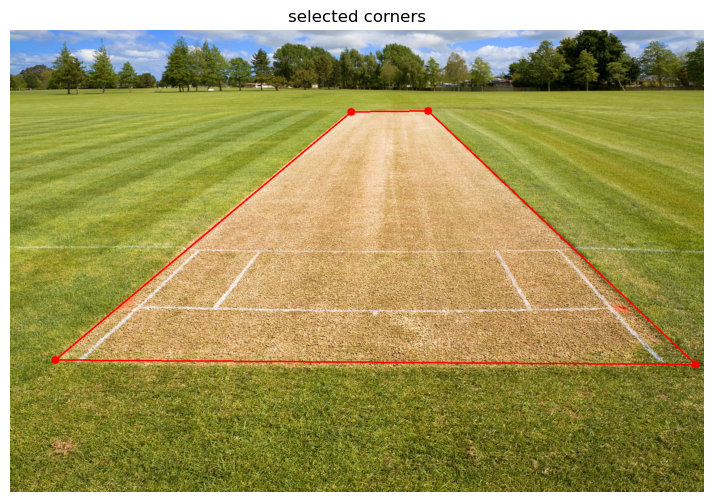

In [34]:
# dst_pts are the clicked corners (TL, TR, BR, BL)
dst_pts = points.copy()

# show selected points
vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
pts_int = dst_pts.astype(int)
for pt in pts_int:
    cv2.circle(vis, tuple(pt), 8, (255, 0, 0), -1)
for i in range(4):
    cv2.line(vis, tuple(pts_int[i]), tuple(pts_int[(i+1)%4]), (255, 0, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(vis)
plt.title('selected corners')
plt.axis('off')
plt.show()

### Load flag

flag size: 318 x 159


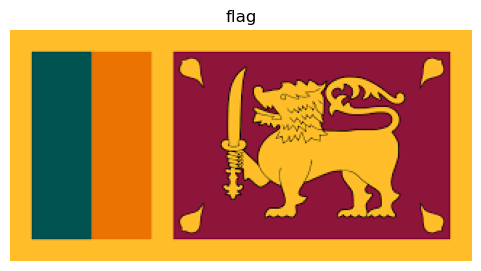

In [35]:
# load the sri lankan flag
flag = cv2.imread('sl_flag.png')
flag_rgb = cv2.cvtColor(flag, cv2.COLOR_BGR2RGB)
fh, fw = flag.shape[:2]
print(f'flag size: {fw} x {fh}')

plt.figure(figsize=(6, 3))
plt.imshow(flag_rgb)
plt.title('flag')
plt.axis('off')
plt.show()

### Homography and warp